# **Major Course Output**
**STINTSY Section S21**

Presented by: **Learning Models**
- Chan, Sidney Sy
- Hsu, Aldrin Gamad
- Siongco, Raine Margaux Aceret
- Villas, Gabriel


# **Dataset Overview**

For this project, we will be using the **Student Performance** dataset from _Using data mining to predict secondary school student performance_ (Cortez and Silva, 2008). The dataset is divided into two: student-mat.csv (for students who took Math) and student-por.csv (for students who took Portuguese). Listed below are the 30 variables in this dataset:

school - student's school (binary: 'GP' - Gabriel Pereira or 'MS' - Mousinho da Silveira)

sex - student's sex (binary: 'F' - female or 'M' - male)

age - student's age (numeric: from 15 to 22)

address - student's home address type (binary: 'U' - urban or 'R' - rural)

famsize - family size (binary: 'LE3' - less or equal to 3 or 'GT3' - greater than 3)

Pstatus - parent's cohabitation status (binary: 'T' - living together or 'A' - apart)

Medu - mother's education (numeric: 0 - none,  1 - primary education (4th grade), 2 â€“ 5th to 9th grade, 3 â€“ secondary education or 4 â€“ higher education)

Fedu - father's education (numeric: 0 - none,  1 - primary education (4th grade), 2 â€“ 5th to 9th grade, 3 â€“ secondary education or 4 â€“ higher education)

Mjob - mother's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')

Fjob - father's job (nominal: 'teacher', 'health' care related, civil 'services' (e.g. administrative or police), 'at_home' or 'other')

reason - reason to choose this school (nominal: close to 'home', school 'reputation', 'course' preference or 'other')

guardian - student's guardian (nominal: 'mother', 'father' or 'other')

traveltime - home to school travel time (numeric: 1 - <15 min., 2 - 15 to 30 min., 3 - 30 min. to 1 hour, or 4 - >1 hour)

studytime - weekly study time (numeric: 1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)

failures - number of past class failures (numeric: n if 1<=n<3, else 4)

schoolsup - extra educational support (binary: yes or no)

famsup - family educational support (binary: yes or no)

paid - extra paid classes within the course subject (Math or Portuguese) (binary: yes or no)

activities - extra-curricular activities (binary: yes or no)

nursery - attended nursery school (binary: yes or no)

higher - wants to take higher education (binary: yes or no)

internet - Internet access at home (binary: yes or no)

romantic - with a romantic relationship (binary: yes or no)

famrel - quality of family relationships (numeric: from 1 - very bad to 5 - excellent)

freetime - free time after school (numeric: from 1 - very low to 5 - very high)

goout - going out with friends (numeric: from 1 - very low to 5 - very high)

Dalc - workday alcohol consumption (numeric: from 1 - very low to 5 - very high)

Walc - weekend alcohol consumption (numeric: from 1 - very low to 5 - very high)

health - current health status (numeric: from 1 - very bad to 5 - very good)

absences - number of school absences (numeric: from 0 to 93)

[These grades are related with the course subject, Math or Portuguese:]
G1 - first period grade (numeric: from 0 to 20)

G2 - second period grade (numeric: from 0 to 20)

G3 - final grade (numeric: from 0 to 20, output target)

Given these variables, the goal of our project is to predict any student's **alcohol consumption**, which is the average of Dalc and Walc. 

# **Data Preparation**

This section prepares raw source files into one consistent modeling table. The math and Portuguese datasets are loaded, aligned, merged, encoded, and cleaned so all predictors can be represented numerically and used by machine learning models. These steps are necessary because mixed data types and subject-specific missing values would otherwise cause unreliable model training and unfair model comparisons.

In [1]:
# Imports for Data Preparation and EDA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import csv
import math
import pandas as pd

In [2]:
# To allow us to scroll through all the columns of our dataframes
pd.set_option('display.max_columns', None)

The **Student Performance** dataset from _Using data mining to predict secondary school student performance_ (2008) is comprised of two csv files, one for students who took Math and another for those who took Portuguese. To start, we import each of these as individual datasets.

In [3]:
# Importing datasets using csv files
student_math = pd.read_csv('student-mat.csv', sep=';')
student_port = pd.read_csv('student-por.csv', sep=';')

In [4]:
student_math.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [5]:
student_port.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,0,yes,no,no,no,yes,yes,yes,no,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,no,yes,yes,yes,yes,yes,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,no,no,yes,yes,no,no,4,3,2,1,2,5,0,11,13,13


Based on the first few rows, both datasets seem to cover the exact same students, apart from the variables related to their chosen subject (failures, absences, G1, G2, and G3).

In [6]:
student_math.tail(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
390,MS,M,20,U,LE3,A,2,2,services,services,course,other,1,2,2,no,yes,yes,no,yes,yes,no,no,5,5,4,4,5,4,11,9,9,9
391,MS,M,17,U,LE3,T,3,1,services,services,course,mother,2,1,0,no,no,no,no,no,yes,yes,no,2,4,5,3,4,2,3,14,16,16
392,MS,M,21,R,GT3,T,1,1,other,other,course,other,1,1,3,no,no,no,no,no,yes,no,no,5,5,3,3,3,3,3,10,8,7
393,MS,M,18,R,LE3,T,3,2,services,other,course,mother,3,1,0,no,no,no,no,no,yes,yes,no,4,4,1,3,4,5,0,11,12,10
394,MS,M,19,U,LE3,T,1,1,other,at_home,course,father,1,1,0,no,no,no,no,yes,yes,yes,no,3,2,3,3,3,5,5,8,9,9


In [7]:
student_port.tail(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
644,MS,F,19,R,GT3,T,2,3,services,other,course,mother,1,3,1,no,no,no,yes,no,yes,yes,no,5,4,2,1,2,5,4,10,11,10
645,MS,F,18,U,LE3,T,3,1,teacher,services,course,mother,1,2,0,no,yes,no,no,yes,yes,yes,no,4,3,4,1,1,1,4,15,15,16
646,MS,F,18,U,GT3,T,1,1,other,other,course,mother,2,2,0,no,no,no,yes,yes,yes,no,no,1,1,1,1,1,5,6,11,12,9
647,MS,M,17,U,LE3,T,3,1,services,services,course,mother,2,1,0,no,no,no,no,no,yes,yes,no,2,4,5,3,4,2,6,10,10,10
648,MS,M,18,R,LE3,T,3,2,services,other,course,mother,3,1,0,no,no,no,no,no,yes,yes,no,4,4,1,3,4,5,4,10,11,11


However, both datasets differ significantly when viewed from their last few rows, with the Portuguese dataset having more students than the Math dataset. This shows that before implementing machine learning models for this project, both datasets must be merged to include students that took either Math or Portuguese and those who took both subjects.

Before we combine the two datasets, we first checked if they have any improper Zero or NaN values.

In [8]:
# To check both datasets for zero values
print("Math Dataset Zeros")
print((student_math == 0).sum())

print("\nPortuguese Dataset Zeros")
print((student_port == 0).sum())

Math Dataset Zeros
school          0
sex             0
age             0
address         0
famsize         0
Pstatus         0
Medu            3
Fedu            2
Mjob            0
Fjob            0
reason          0
guardian        0
traveltime      0
studytime       0
failures      312
schoolsup       0
famsup          0
paid            0
activities      0
nursery         0
higher          0
internet        0
romantic        0
famrel          0
freetime        0
goout           0
Dalc            0
Walc            0
health          0
absences      115
G1              0
G2             13
G3             38
dtype: int64

Portuguese Dataset Zeros
school          0
sex             0
age             0
address         0
famsize         0
Pstatus         0
Medu            6
Fedu            7
Mjob            0
Fjob            0
reason          0
guardian        0
traveltime      0
studytime       0
failures      549
schoolsup       0
famsup          0
paid            0
activities      0
nurser

Based on this, the variables that contain zero values in the datasets are Medu, Fedu, failures, absences, G1, G2, and G3. 0 in Medu and Fedu means "no education", so it is a possible value for this dataset. Zeroes in failures and absences are also reasonable for fairly responsible students. Zeroes in the three Grade columns are also possible but rare. Thus, both datasets do not have any improper Zero values.

In [9]:
# To check both datasets for missing values 
print("Math Dataset Missing Values")
print(student_math.isnull().sum())

print("\nPortuguese Dataset Missing Values")
print(student_port.isnull().sum())

Math Dataset Missing Values
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Portuguese Dataset Missing Values
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime    

Based on this, all of the variables on both datasets do not have any NaN values. Thus, both datasets are ready for merging.

# **Exploratory Data Analysis**

This section examines the prepared dataset before training models by using descriptive statistics, distributions, and relationship plots. The purpose is to understand class balance, feature behavior, and possible signal strength for predicting alcohol outcomes. Interpreting these patterns helps justify later modeling choices and highlights early risks such as imbalance, weak predictors, or redundant variables.

First, since we aim to merge the Math and Portuguese datasets, we need to ensure that the combined dataframe has unique grade, failures, and absences columns for each subject. We only need G3 from each of the original datasets, so we removed G1 and G2 and renamed their respective failures, absences, and G3 columns.

In [10]:
# Rename failures, absences, and G3 and remove G1 and G2 for both datasets
math_df = student_math.drop(columns=['G1', 'G2']).rename(columns={
    'G3': 'math_grade',
    'failures': 'math_failures',
    'absences': 'math_absences'
})

port_df = student_port.drop(columns=['G1', 'G2']).rename(columns={
    'G3': 'port_grade',
    'failures': 'port_failures',
    'absences': 'port_absences'
})

Next, we create combined_df by merging math_df and port_df on a set of stable columns (which should not vary for the students even if they took both subjects).

In [11]:
# Create combined_df by merging math_df and port_df on the stable columns
stable_cols = ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian',
               'traveltime', 'studytime', 'romantic', 'freetime', 'goout', 'Dalc', 'Walc', 'health',
               'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'famrel']

combined_df = pd.merge(math_df, port_df, on=stable_cols, how='outer', suffixes=('_math', '_port'))
print("Combined rows:", len(combined_df))

Combined rows: 843


In [12]:
combined_df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,math_failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,math_absences,math_grade,port_failures,port_absences,port_grade
0,GP,F,15,R,GT3,T,1,1,at_home,other,home,mother,2,4,1.0,yes,yes,yes,yes,yes,yes,yes,no,3,1,2,1,1,1,2.0,10.0,0.0,4.0,13.0
1,GP,F,15,R,GT3,T,1,1,other,other,course,mother,3,1,NaN,no,no,no,yes,yes,yes,yes,yes,5,5,5,1,1,1,NaN,NaN,1.0,2.0,9.0
2,GP,F,15,R,GT3,T,1,1,other,other,reputation,mother,1,2,2.0,yes,yes,no,no,no,yes,yes,yes,3,3,4,2,4,5,2.0,5.0,0.0,2.0,11.0
3,GP,F,15,R,GT3,T,2,2,at_home,other,reputation,mother,1,1,NaN,yes,yes,no,yes,yes,yes,no,no,4,3,1,1,1,2,NaN,NaN,0.0,8.0,12.0
4,GP,F,15,R,GT3,T,2,2,at_home,other,reputation,mother,1,1,0.0,yes,yes,yes,yes,yes,yes,no,no,4,3,1,1,1,2,8.0,13.0,NaN,NaN,NaN
5,GP,F,15,R,GT3,T,2,4,services,health,course,mother,1,3,NaN,yes,yes,no,yes,yes,yes,yes,no,4,3,2,1,1,5,NaN,NaN,0.0,2.0,10.0
6,GP,F,15,R,GT3,T,2,4,services,health,course,mother,1,3,0.0,yes,yes,yes,yes,yes,yes,yes,no,4,3,2,1,1,5,2.0,8.0,NaN,NaN,NaN
7,GP,F,15,R,GT3,T,3,3,services,services,reputation,other,2,3,2.0,no,yes,yes,yes,yes,yes,yes,yes,4,2,1,2,3,3,8.0,10.0,0.0,2.0,13.0
8,GP,F,15,R,GT3,T,3,4,services,health,course,mother,1,3,NaN,yes,yes,no,yes,yes,yes,yes,no,4,3,2,1,1,5,NaN,NaN,0.0,2.0,12.0
9,GP,F,15,R,GT3,T,3,4,services,health,course,mother,1,3,0.0,yes,yes,yes,yes,yes,yes,yes,no,4,3,2,1,1,5,2.0,11.0,NaN,NaN,NaN


In [13]:
# Rearrange combined_df to make it more intuitive to read and work with
cols = ['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 
        'traveltime', 'studytime', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 
        'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 
        'math_failures', 'port_failures',
        'math_absences', 'port_absences',
        'math_grade', 'port_grade']

combined_df = combined_df[cols]

In [14]:
# View rearranged combined_df
combined_df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,math_failures,port_failures,math_absences,port_absences,math_grade,port_grade
0,GP,F,15,R,GT3,T,1,1,at_home,other,home,mother,2,4,yes,yes,yes,yes,yes,yes,yes,no,3,1,2,1,1,1,1.0,0.0,2.0,4.0,10.0,13.0
1,GP,F,15,R,GT3,T,1,1,other,other,course,mother,3,1,no,no,no,yes,yes,yes,yes,yes,5,5,5,1,1,1,NaN,1.0,NaN,2.0,NaN,9.0
2,GP,F,15,R,GT3,T,1,1,other,other,reputation,mother,1,2,yes,yes,no,no,no,yes,yes,yes,3,3,4,2,4,5,2.0,0.0,2.0,2.0,5.0,11.0
3,GP,F,15,R,GT3,T,2,2,at_home,other,reputation,mother,1,1,yes,yes,no,yes,yes,yes,no,no,4,3,1,1,1,2,NaN,0.0,NaN,8.0,NaN,12.0
4,GP,F,15,R,GT3,T,2,2,at_home,other,reputation,mother,1,1,yes,yes,yes,yes,yes,yes,no,no,4,3,1,1,1,2,0.0,NaN,8.0,NaN,13.0,NaN
5,GP,F,15,R,GT3,T,2,4,services,health,course,mother,1,3,yes,yes,no,yes,yes,yes,yes,no,4,3,2,1,1,5,NaN,0.0,NaN,2.0,NaN,10.0
6,GP,F,15,R,GT3,T,2,4,services,health,course,mother,1,3,yes,yes,yes,yes,yes,yes,yes,no,4,3,2,1,1,5,0.0,NaN,2.0,NaN,8.0,NaN
7,GP,F,15,R,GT3,T,3,3,services,services,reputation,other,2,3,no,yes,yes,yes,yes,yes,yes,yes,4,2,1,2,3,3,2.0,0.0,8.0,2.0,10.0,13.0
8,GP,F,15,R,GT3,T,3,4,services,health,course,mother,1,3,yes,yes,no,yes,yes,yes,yes,no,4,3,2,1,1,5,NaN,0.0,NaN,2.0,NaN,12.0
9,GP,F,15,R,GT3,T,3,4,services,health,course,mother,1,3,yes,yes,yes,yes,yes,yes,yes,no,4,3,2,1,1,5,0.0,NaN,2.0,NaN,11.0,NaN


The current combined_df still has columns with categorical values. To make this dataframe more suitable for machine learning, we must perform encoding on these categorical varibles.

First, we encoded the Yes/No binary variables by changing Yes to 1 and No to 0.

In [15]:
# Encoding for Yes/No Binary Categorical Variables
binary_cols = [
    "schoolsup","famsup","paid","activities",
    "nursery","higher","internet","romantic"
]

combined_df[binary_cols] = combined_df[binary_cols].replace({"yes":1, "no":0})

C:\Users\cheme\AppData\Local\Temp\ipykernel_19344\515027620.py:7: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_df[binary_cols] = combined_df[binary_cols].replace({"yes":1, "no":0})


Next, we encoded the other binary categorical variables by assigning one categorical value to 0 and the other to 1.

In [16]:
# Encoding for Other Binary Categorical Variables
combined_df["sex"] = combined_df["sex"].map({"F":0, "M":1})
combined_df["address"] = combined_df["address"].map({"R":0, "U":1})
combined_df["Pstatus"] = combined_df["Pstatus"].map({"A":0, "T":1})
combined_df["famsize"] = combined_df["famsize"].map({"LE3":0, "GT3":1})
combined_df["school"] = combined_df["school"].map({"GP":0, "MS":1})

Lastly, to encode the categorical variables with more than 2 categories, we used the get_dummies function to create new columns for each category.

In [17]:
# Encoding for Categorical Variables with More than 2 Categories
combined_df = pd.get_dummies(
    combined_df,
    columns=["Mjob","Fjob","reason","guardian"],
    drop_first=True
)

In [18]:
# View latest combined_df
combined_df.head(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,math_failures,port_failures,math_absences,port_absences,math_grade,port_grade,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other
0,0,0,15,0,1,1,1,1,2,4,1,1,1,1,1,1,1,0,3,1,2,1,1,1,1.0,0.0,2.0,4.0,10.0,13.0,False,False,False,False,False,True,False,False,True,False,False,True,False
1,0,0,15,0,1,1,1,1,3,1,0,0,0,1,1,1,1,1,5,5,5,1,1,1,NaN,1.0,NaN,2.0,NaN,9.0,False,True,False,False,False,True,False,False,False,False,False,True,False
2,0,0,15,0,1,1,1,1,1,2,1,1,0,0,0,1,1,1,3,3,4,2,4,5,2.0,0.0,2.0,2.0,5.0,11.0,False,True,False,False,False,True,False,False,False,False,True,True,False
3,0,0,15,0,1,1,2,2,1,1,1,1,0,1,1,1,0,0,4,3,1,1,1,2,NaN,0.0,NaN,8.0,NaN,12.0,False,False,False,False,False,True,False,False,False,False,True,True,False
4,0,0,15,0,1,1,2,2,1,1,1,1,1,1,1,1,0,0,4,3,1,1,1,2,0.0,NaN,8.0,NaN,13.0,NaN,False,False,False,False,False,True,False,False,False,False,True,True,False
5,0,0,15,0,1,1,2,4,1,3,1,1,0,1,1,1,1,0,4,3,2,1,1,5,NaN,0.0,NaN,2.0,NaN,10.0,False,False,True,False,True,False,False,False,False,False,False,True,False
6,0,0,15,0,1,1,2,4,1,3,1,1,1,1,1,1,1,0,4,3,2,1,1,5,0.0,NaN,2.0,NaN,8.0,NaN,False,False,True,False,True,False,False,False,False,False,False,True,False
7,0,0,15,0,1,1,3,3,2,3,0,1,1,1,1,1,1,1,4,2,1,2,3,3,2.0,0.0,8.0,2.0,10.0,13.0,False,False,True,False,False,False,True,False,False,False,True,False,True
8,0,0,15,0,1,1,3,4,1,3,1,1,0,1,1,1,1,0,4,3,2,1,1,5,NaN,0.0,NaN,2.0,NaN,12.0,False,False,True,False,True,False,False,False,False,False,False,True,False
9,0,0,15,0,1,1,3,4,1,3,1,1,1,1,1,1,1,0,4,3,2,1,1,5,0.0,NaN,2.0,NaN,11.0,NaN,False,False,True,False,True,False,False,False,False,False,False,True,False


The new categorical columns show values of True/False, but to make it in line with the 0/1 values found in certain other parts of the dataframe, we can convert those into 0/1 values.

In [19]:
#COnvert columns with True/False values to 0/1
bool_cols = combined_df.select_dtypes(include="bool").columns
combined_df[bool_cols] = combined_df[bool_cols].astype(int)

Currently, students who did not took one of the subjects have NaN values for those respective absences, failures, and grade columns. To resolve this, we created 2 new columns to show if they took the indicated subject. Then, we replaced all the NaN values with zeroes.

In [20]:
# For resolving NaN values for students who only took one of the two subjects   
# Indicator variables on if they took Math and/or Portuguese
combined_df["took_math"] = combined_df["math_grade"].notna().astype(int)
combined_df["took_port"] = combined_df["port_grade"].notna().astype(int)

# Fill NaNs for absences, failures, and grades with 0s
combined_df["math_absences"] = combined_df["math_absences"].fillna(0)
combined_df["port_absences"] = combined_df["port_absences"].fillna(0)

combined_df["math_failures"] = combined_df["math_failures"].fillna(0)
combined_df["port_failures"] = combined_df["port_failures"].fillna(0)

combined_df["math_grade"] = combined_df["math_grade"].fillna(0)
combined_df["port_grade"] = combined_df["port_grade"].fillna(0)

Lastly, we created a new column called alcohol_consumption (which is the average of Dalc and Walc) and removed the Dalc and Walc columns from combined_df.

In [21]:
# Create new column (alcohol_consumption) by averaging Dalc and Walc, then remove Dalc and Walc
combined_df["alcohol_consumption"] = (combined_df["Dalc"] + combined_df["Walc"]) / 2
combined_df = combined_df.drop(columns=["Dalc", "Walc"])

This is the latest state of combined_df:

In [22]:
# View latest combined_df
combined_df.tail(10)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,health,math_failures,port_failures,math_absences,port_absences,math_grade,port_grade,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,took_math,took_port,alcohol_consumption
833,1,1,19,0,1,1,1,1,3,1,0,1,0,0,1,1,1,0,4,4,4,5,1.0,1.0,4.0,4.0,8.0,10.0,0,1,0,0,0,1,0,0,1,0,0,0,1,1,1,3.0
834,1,1,19,0,1,1,1,1,3,2,0,0,0,0,1,1,1,0,5,4,4,2,3.0,1.0,8.0,8.0,8.0,11.0,0,1,0,0,0,0,1,0,1,0,0,0,1,1,1,3.0
835,1,1,19,0,1,1,1,1,2,1,0,0,0,0,1,1,0,0,4,3,2,5,1.0,1.0,0.0,0.0,0.0,0.0,0,1,0,0,0,0,1,0,0,1,0,1,0,1,1,2.0
836,1,1,19,1,1,1,1,1,1,2,0,1,0,1,1,0,1,0,4,4,3,4,0.0,2.0,0.0,2.0,0.0,10.0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,1,3.5
837,1,1,19,1,1,1,2,1,2,1,0,0,0,1,0,0,1,1,4,4,3,5,0.0,3.0,0.0,4.0,0.0,9.0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,1,2.0
838,1,1,19,1,1,1,3,2,2,1,0,0,0,1,1,1,0,0,3,2,1,3,0.0,3.0,0.0,4.0,0.0,9.0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,1,1.0
839,1,1,19,1,0,1,1,1,1,1,0,0,0,0,1,1,1,0,3,2,3,5,0.0,0.0,5.0,0.0,9.0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,3.0
840,1,1,20,0,1,1,1,1,2,1,0,1,0,0,1,0,1,1,4,4,3,4,0.0,1.0,0.0,12.0,0.0,10.0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,1,3.0
841,1,1,20,1,0,0,2,2,1,2,0,1,1,0,1,1,0,0,5,5,4,4,2.0,0.0,11.0,0.0,9.0,0.0,0,0,1,0,0,0,1,0,0,0,0,0,1,1,0,4.5
842,1,1,21,0,1,1,1,1,1,1,0,0,0,0,0,1,0,0,5,5,3,3,3.0,0.0,3.0,0.0,7.0,0.0,0,1,0,0,0,1,0,0,0,0,0,0,1,1,0,3.0


## Statistical Summary

In [23]:
# Statistical summary of all numeric features
combined_df.describe()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,traveltime,studytime,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,health,math_failures,port_failures,math_absences,port_absences,math_grade,port_grade,Mjob_health,Mjob_other,Mjob_services,Mjob_teacher,Fjob_health,Fjob_other,Fjob_services,Fjob_teacher,reason_home,reason_other,reason_reputation,guardian_mother,guardian_other,took_math,took_port,alcohol_consumption
count,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.00000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000,843.000000
mean,0.293001,0.411625,16.763938,0.722420,0.699881,0.883749,2.588375,2.360617,1.52669,1.976275,0.107948,0.639383,0.243179,0.488731,0.805457,0.911032,0.793594,0.364176,3.935943,3.176750,3.169632,3.524318,0.156584,0.170819,2.674970,2.817319,4.880190,9.166074,0.079478,0.377224,0.227758,0.124555,0.040332,0.568209,0.276394,0.053381,0.240807,0.109134,0.238434,0.702254,0.074733,0.468565,0.769870,1.889680
std,0.455409,0.492420,1.235858,0.448071,0.458581,0.320717,1.132633,1.095430,0.72465,0.835329,0.310499,0.480465,0.429257,0.500170,0.396084,0.284867,0.404965,0.481484,0.930188,1.043396,1.148552,1.439291,0.535366,0.528749,6.172206,4.353155,6.071711,5.759919,0.270644,0.484979,0.419635,0.330410,0.196854,0.495620,0.447479,0.224925,0.427827,0.311992,0.426379,0.457539,0.263116,0.499307,0.421166,0.983377
min,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,16.000000,0.000000,0.000000,1.000000,2.000000,1.000000,1.00000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000
50%,0.000000,0.000000,17.000000,1.000000,1.000000,1.000000,3.000000,2.000000,1.00000,2.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,3.000000,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.500000
75%,1.000000,1.000000,18.000000,1.000000,1.000000,1.000000,4.000000,3.000000,2.00000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,4.000000,4.000000,5.000000,0.000000,0.000000,3.000000,4.000000,10.000000,13.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,2.500000
max,1.000000,1.000000,22.000000,1.000000,1.000000,1.000000,4.000000,4.000000,4.00000,4.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,75.000000,32.000000,20.000000,19.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000


## Label Distribution

We examine the distribution of `alcohol_consumption` (the average of `Dalc` and `Walc`). Since the values range from 1.0 to 5.0 in 0.5 increments, this is effectively an ordinal label. Understanding the class distribution is critical to detecting imbalance before modeling.

Value counts for alcohol_consumption:
alcohol_consumption
1.0    309
1.5    150
2.0    134
2.5     97
3.0     67
3.5     37
4.0     22
4.5     10
5.0     17
Name: count, dtype: int64


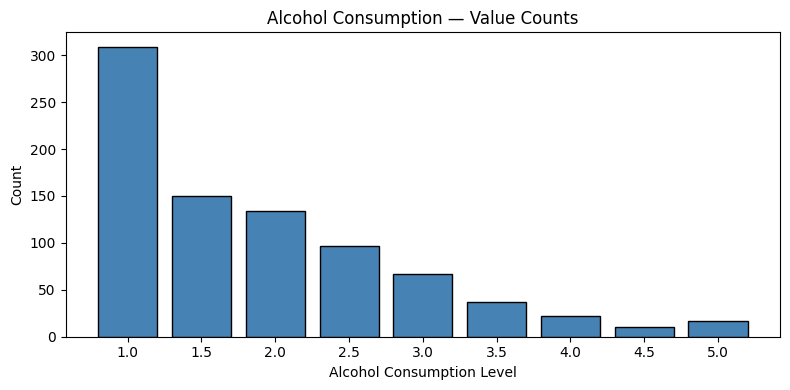

In [24]:
# Distribution of alcohol_consumption values (bar chart only)
print("Value counts for alcohol_consumption:")
val_counts = combined_df["alcohol_consumption"].value_counts().sort_index()
print(val_counts)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(val_counts.index.astype(str), val_counts.values, color="steelblue", edgecolor="black")
ax.set_title("Alcohol Consumption — Value Counts")
ax.set_xlabel("Alcohol Consumption Level")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

Most students fall at the lower end of the alcohol consumption scale — the 1.0 and 1.5 levels account for the majority of the data. The distribution drops off sharply at higher levels (3.5–5.0), indicating significant class imbalance that will need to be addressed during model training, such as through oversampling or class weighting.

## Feature Distributions

We examine the distributions of key numeric features to spot skewness, outliers, or unusual patterns.

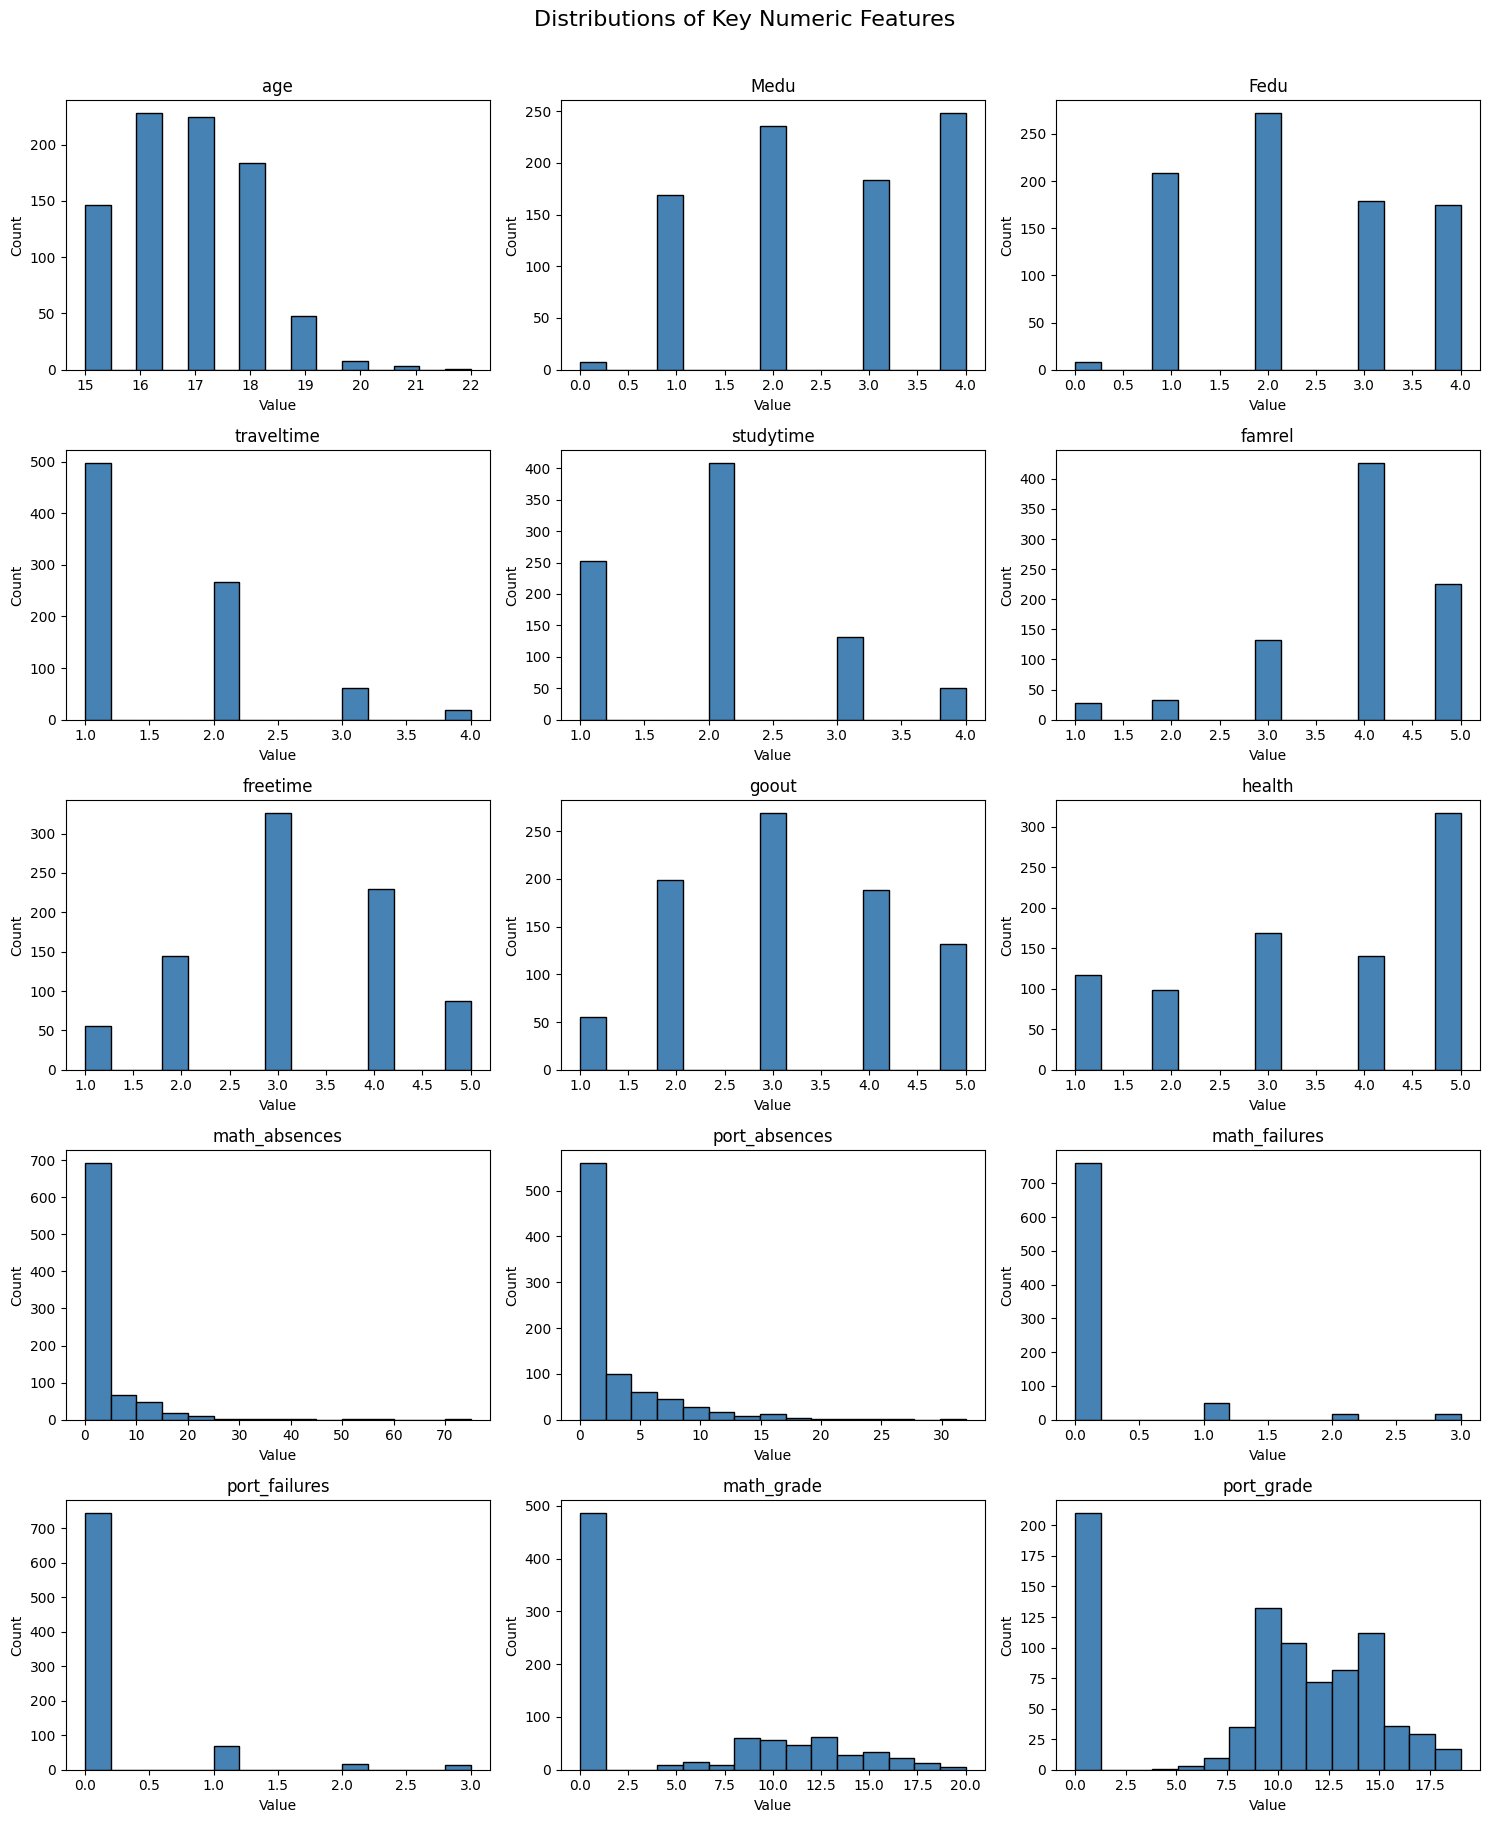

In [25]:
# Histograms for key numeric features
numeric_features = ["age", "Medu", "Fedu", "traveltime", "studytime",
                    "famrel", "freetime", "goout", "health",
                    "math_absences", "port_absences",
                    "math_failures", "port_failures",
                    "math_grade", "port_grade"]

fig, axes = plt.subplots(5, 3, figsize=(15, 18))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(combined_df[col].dropna(), bins=15, edgecolor="black", color="steelblue")
    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.suptitle("Distributions of Key Numeric Features", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

Several numeric features show skewed or clustered distributions. Absence columns (`math_absences`, `port_absences`) are heavily right-skewed, with most students having few or no absences and a small number having very high counts. Grade columns (`math_grade`, `port_grade`) show a left-leaning peak around 10–12, while ordinal features like `studytime` and `traveltime` cluster at the lower levels. These patterns suggest that normalization and outlier handling may be beneficial before modeling.

## Categorical Feature Distributions

We examine the distribution of categorical features to understand how students are distributed across groups such as sex, school, and address.

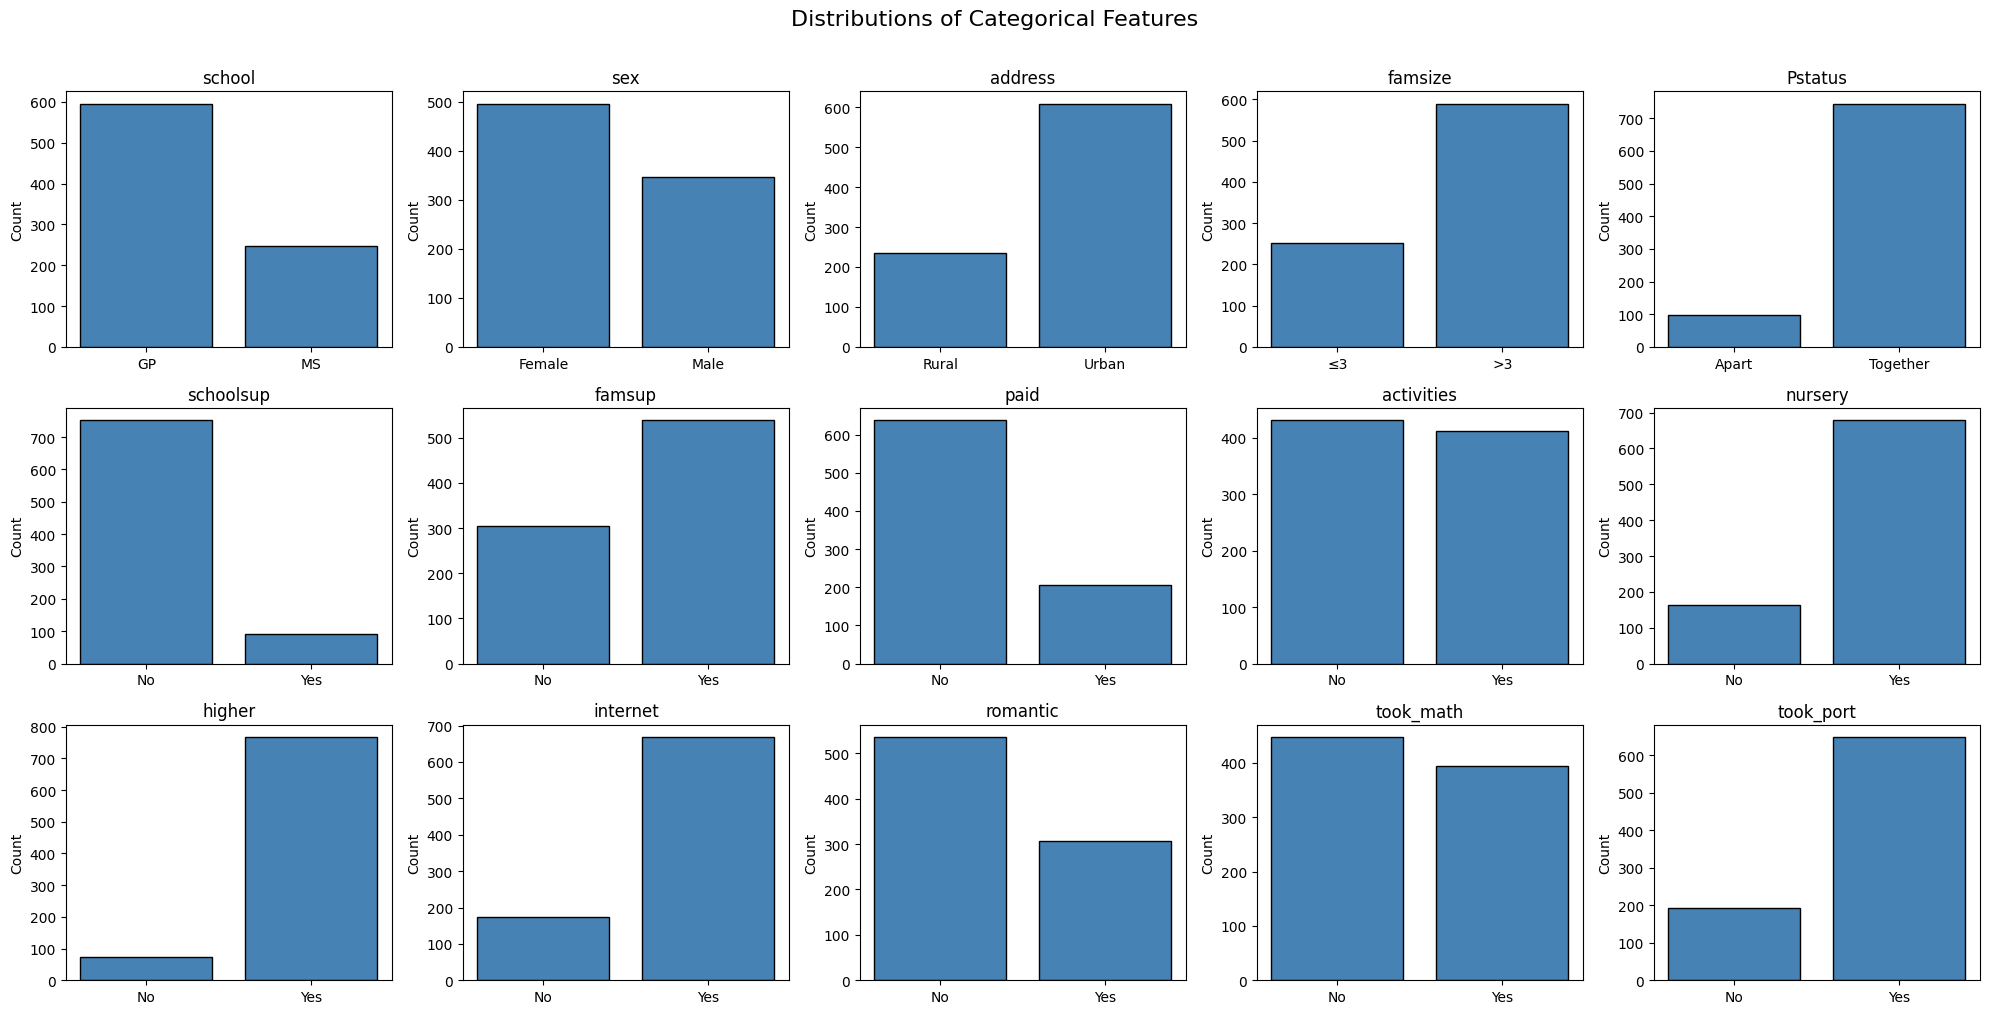

In [26]:
# Bar charts for binary/encoded categorical features
categorical_features = ["school", "sex", "address", "famsize", "Pstatus",
                        "schoolsup", "famsup", "paid", "activities",
                        "nursery", "higher", "internet", "romantic",
                        "took_math", "took_port"]

label_maps = {
    "school":    {0: "GP", 1: "MS"},
    "sex":       {0: "Female", 1: "Male"},
    "address":   {0: "Rural", 1: "Urban"},
    "famsize":   {0: "≤3", 1: ">3"},
    "Pstatus":   {0: "Apart", 1: "Together"},
}
binary_01 = ["schoolsup", "famsup", "paid", "activities",
             "nursery", "higher", "internet", "romantic",
             "took_math", "took_port"]
for col in binary_01:
    label_maps[col] = {0: "No", 1: "Yes"}

fig, axes = plt.subplots(3, 5, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_features):
    counts = combined_df[col].value_counts().sort_index()
    labels = [label_maps[col].get(k, str(k)) for k in counts.index]
    axes[i].bar(labels, counts.values, color="steelblue", edgecolor="black")
    axes[i].set_title(col)
    axes[i].set_ylabel("Count")

plt.suptitle("Distributions of Categorical Features", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

Category frequencies are notably uneven across several features. The majority of students come from school GP, live in urban areas, and have family sizes greater than 3. For binary features, most students have internet access at home and aspire to pursue higher education, while fewer report having a romantic relationship or receiving extra school support. These imbalances can skew learned decision boundaries, so they should be kept in mind during feature selection and model evaluation.

## Alcohol Consumption by Key Categorical Groups

We compare average alcohol consumption across important categorical groups to identify which groups tend to drink more.

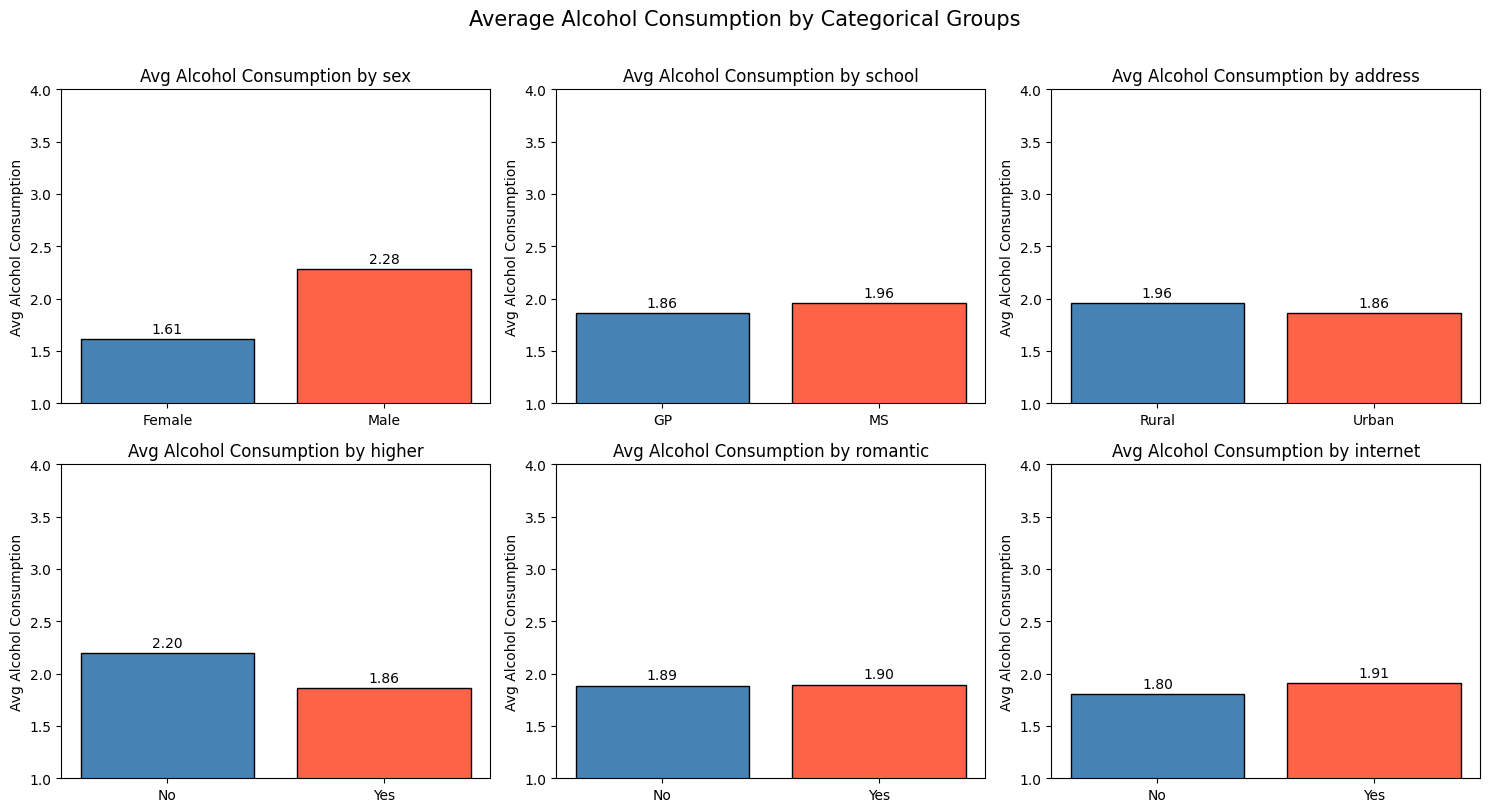

In [27]:
# Average alcohol consumption by key categorical groups
group_cols = {
    "sex":      {0: "Female", 1: "Male"},
    "school":   {0: "GP", 1: "MS"},
    "address":  {0: "Rural", 1: "Urban"},
    "higher":   {0: "No", 1: "Yes"},
    "romantic": {0: "No", 1: "Yes"},
    "internet": {0: "No", 1: "Yes"},
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, lmap) in enumerate(group_cols.items()):
    group_means = combined_df.groupby(col)["alcohol_consumption"].mean()
    labels = [lmap.get(k, str(k)) for k in group_means.index]
    bars = axes[i].bar(labels, group_means.values, color=["steelblue", "tomato"], edgecolor="black")
    axes[i].set_title(f"Avg Alcohol Consumption by {col}")
    axes[i].set_ylabel("Avg Alcohol Consumption")
    axes[i].set_ylim(1, 4)
    for bar, val in zip(bars, group_means.values):
        axes[i].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
                     f"{val:.2f}", ha="center", va="bottom", fontsize=10)

plt.suptitle("Average Alcohol Consumption by Categorical Groups", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

Based on the charts, male students report a notably higher average alcohol consumption (2.28) compared to female students (1.61). Additionally, students who do not plan to pursue higher education have a higher average alcohol consumption (2.20) than those who do (1.86), while other factors like school, address, romantic status, and internet access show very minimal differences.

## Alcohol Consumption vs. Ordinal Features

We use line graphs to show how the average alcohol consumption changes across ordinal feature levels like `goout`, `freetime`, `studytime`, and `health`.

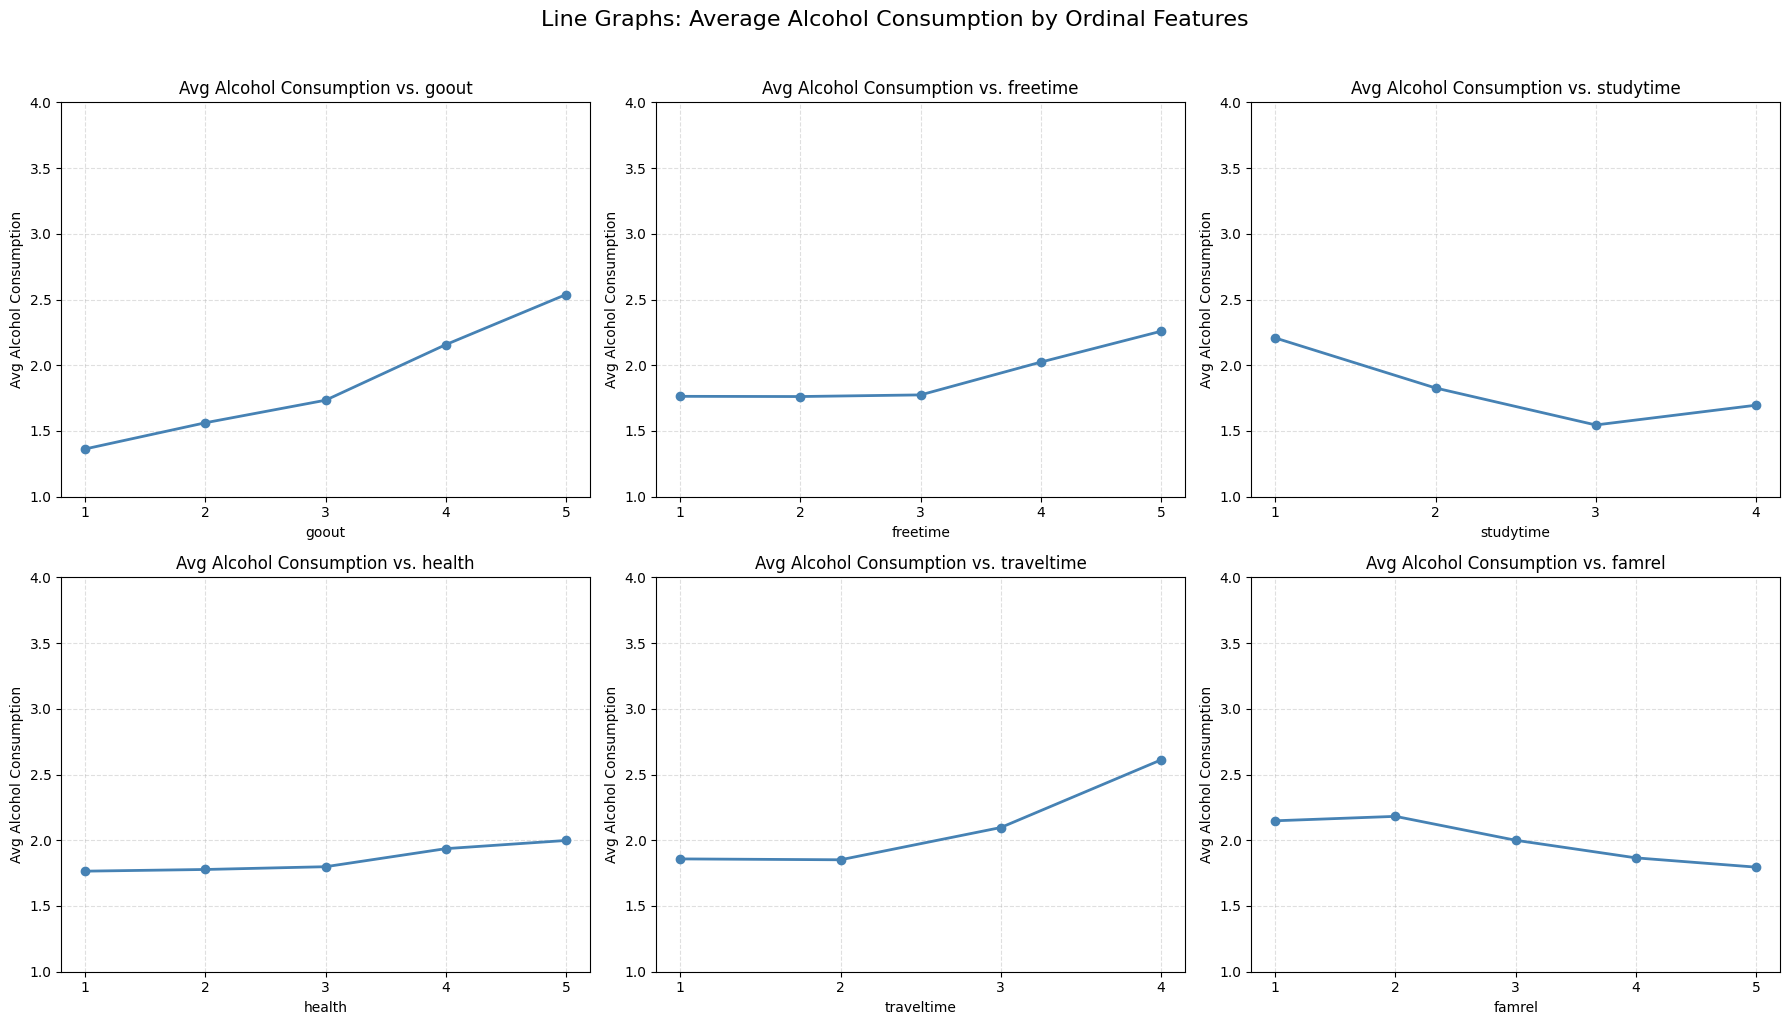

In [28]:
# Line graphs: average alcohol_consumption vs. ordinal feature levels
ordinal_features = ["goout", "freetime", "studytime", "health", "traveltime", "famrel"]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(ordinal_features):
    mean_by_level = combined_df.groupby(col)["alcohol_consumption"].mean().sort_index()
    axes[i].plot(
        mean_by_level.index,
        mean_by_level.values,
        marker="o",
        linewidth=2,
        color="steelblue"
    )
    axes[i].set_title(f"Avg Alcohol Consumption vs. {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Avg Alcohol Consumption")
    axes[i].set_ylim(1, 4)
    axes[i].set_xticks(mean_by_level.index)
    axes[i].grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Line Graphs: Average Alcohol Consumption by Ordinal Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

The line graphs reveal clear directional trends for some features. `goout` (going out with friends) shows a consistent upward trend — students who go out more frequently report higher average alcohol consumption across all levels. `studytime` shows the opposite pattern, with higher study hours associated with lower average consumption. `freetime` also trends upward moderately. In contrast, `health`, `famrel`, and `traveltime` show relatively flat or inconsistent patterns, suggesting weaker relationships with alcohol consumption.

## Correlation Heatmap

We compute the Pearson correlation matrix for all numeric features with respect to `alcohol_consumption`. This helps identify which features are most strongly related to the label and whether any features are redundant (highly correlated with each other).

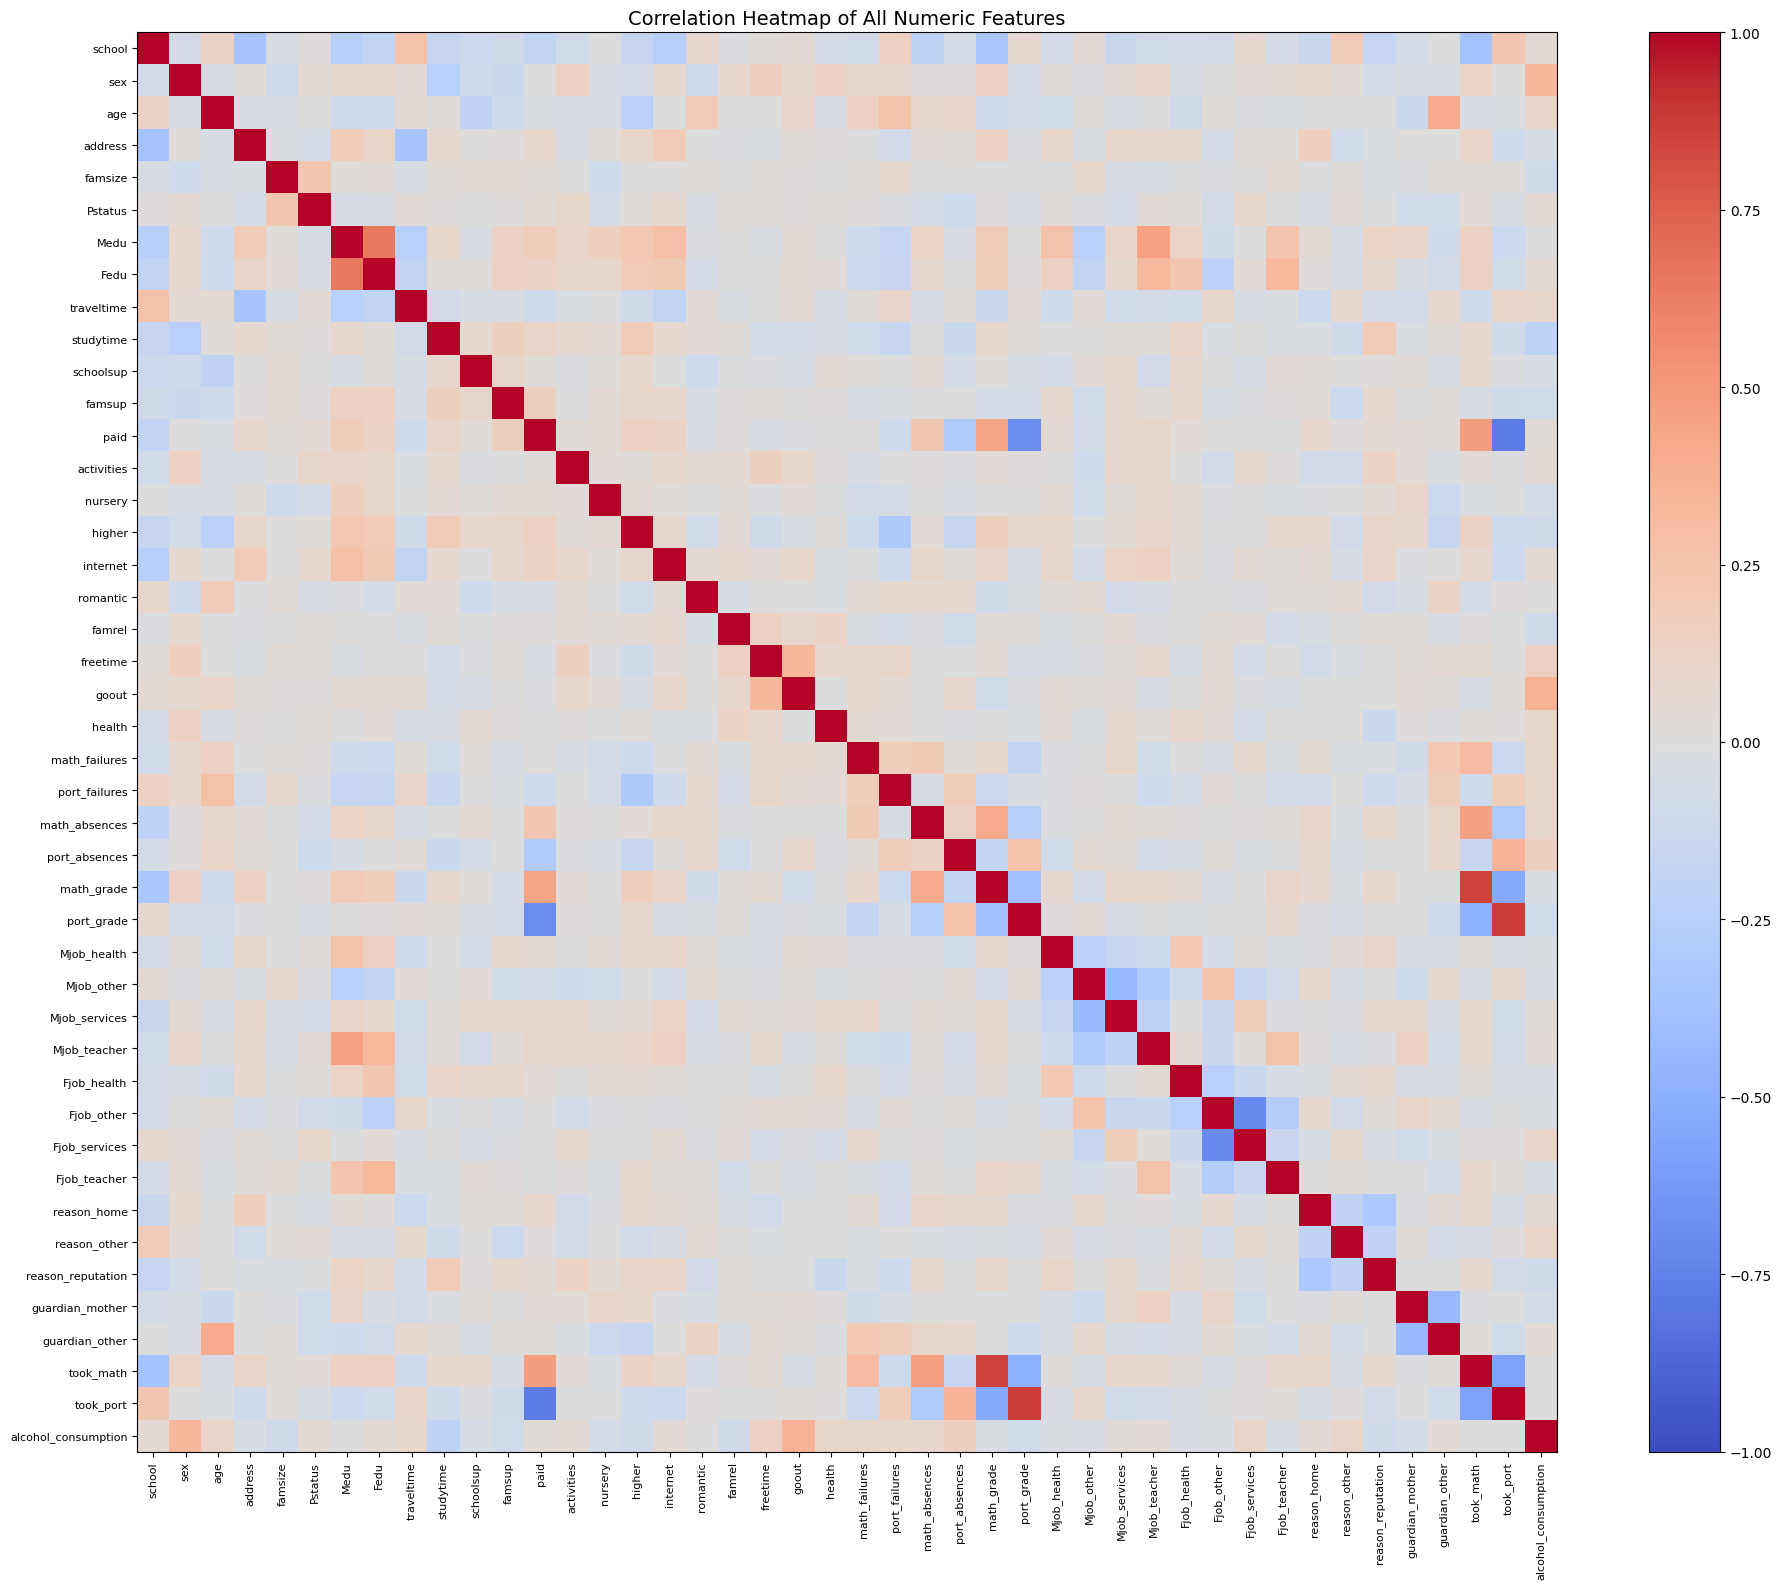

In [29]:
# Correlation heatmap of all numeric columns
numeric_df = combined_df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

fig, ax = plt.subplots(figsize=(20, 16))
im = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)
ax.set_title("Correlation Heatmap of All Numeric Features", fontsize=14)

plt.tight_layout()
plt.show()

The heatmap reveals that most features have weak to moderate correlations with `alcohol_consumption`. A few features stand out with stronger positive correlations (notably `goout` and `freetime`), while `studytime` and `higher` show negative correlations. Some feature pairs also show moderate correlation with each other — for example, `Medu` and `Fedu` (parental education levels), and math vs. Portuguese grade columns — which may introduce redundancy and should be considered during feature selection.

Top 15 features most correlated with alcohol_consumption:
goout                0.362012
sex                  0.335473
studytime            0.209940
port_absences        0.151622
freetime             0.147508
age                  0.115848
reason_other         0.110902
Fjob_services        0.105811
math_failures        0.099399
higher               0.098673
reason_reputation    0.098644
famrel               0.098620
health               0.097137
famsize              0.094576
traveltime           0.090802


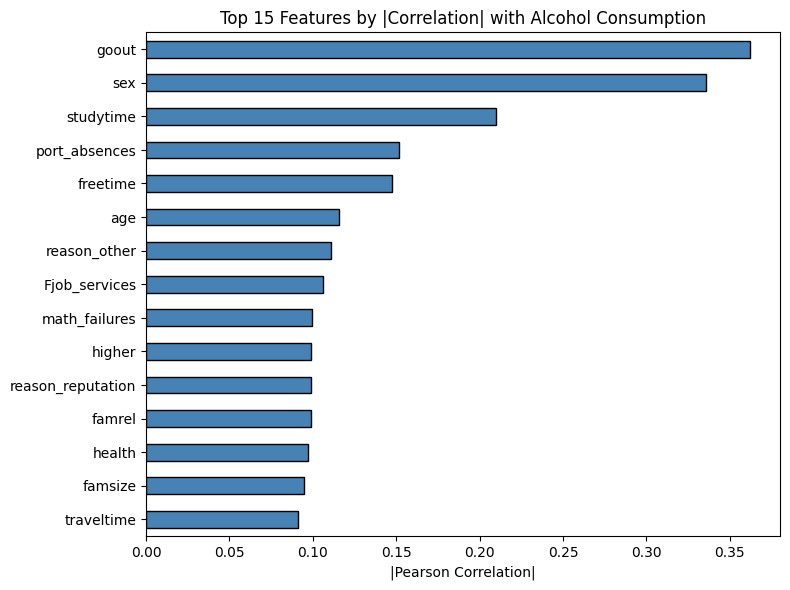

In [30]:
# Top features correlated with alcohol_consumption (sorted by absolute correlation)
alcohol_corr = corr_matrix["alcohol_consumption"].drop("alcohol_consumption").abs().sort_values(ascending=False)

print("Top 15 features most correlated with alcohol_consumption:")
print(alcohol_corr.head(15).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
alcohol_corr.head(15).sort_values().plot(kind="barh", ax=ax, color="steelblue", edgecolor="black")
ax.set_title("Top 15 Features by |Correlation| with Alcohol Consumption")
ax.set_xlabel("|Pearson Correlation|")
plt.tight_layout()
plt.show()

`goout` ranks as the most correlated feature with `alcohol_consumption`, followed by `freetime` and `studytime`. The top features are dominated by lifestyle and behavioral variables, while demographic and grade-related features tend to rank lower. This suggests that a student's social habits are more predictive of alcohol consumption than academic performance or family background alone. These top-ranked features are strong candidates for inclusion in initial model experiments.

## EDA Summary

Based on the analysis above, we note the following key observations:

- **Label distribution**: `alcohol_consumption` is right-skewed — the 1.0 and 1.5 levels account for the majority of students, and the distribution drops off sharply at higher levels (3.5–5.0). This **class imbalance** must be addressed during model training, such as through oversampling or class weighting.
- **Sex effect**: Male students report a notably higher average alcohol consumption (2.28) compared to female students (1.61), making `sex` one of the most distinguishing categorical features.
- **Higher education aspirations**: Students who do not plan to pursue higher education have a higher average alcohol consumption (2.20) than those who do (1.86). Other categorical groups — school, address, romantic status, and internet access — show minimal differences.
- **Strongest correlates**: `goout` ranks as the most positively correlated feature with `alcohol_consumption`, followed by `freetime`. `studytime` shows a consistent negative trend, and `higher` also correlates negatively. Lifestyle and behavioral features dominate the top correlates, while academic and demographic features rank lower.
- **Ordinal feature trends**: `goout` and `freetime` both trend upward with alcohol consumption, while `studytime` trends downward. `health`, `famrel`, and `traveltime` show relatively flat or inconsistent patterns across levels.
- **Grades and absences**: Both math and Portuguese grades show a mild negative correlation with alcohol consumption, while total absences show a mild positive correlation. However, scatter plots confirm considerable overlap — no single feature cleanly separates consumption levels.
- **No missing values** were found in the final merged dataset after preprocessing.

These observations will inform **feature selection** and the choice of **class binning strategy** in the next step.

# **Machine Learning Models**

To make our predictions on the students' alcohol consumption, we will use two classical Machine Learning models (**Regularized Linear Regression** and **Decision Tree**) and one **Neural Network** model. Since all three of these models have ways to deal with the variables with low correlation to alcohol_consumption, we will keep **all** of our features as we do machine learning. Additionally, to gauge the effectiveness of our machine learning models, we will use **Root Mean Squared Error** (ideally close to 0, it represents the average magnitude of error in the model's predictions) and **R<sup>2</sup>** (ideally close to 1, it represents how much of the variance of the target variable is explained by the model).

# 1. Regularized Linear Regression

We will use Linear Regression as our first classical machine learning model as it effectively models continuous values like alcohol_consumption and has relatively easy interpretability. Additionally, we will use Regularized Linear Regression instead of the traditional Linear Regression since the features in this dataset have varying magnitudes (i.e. 0/1, 1-5, 0-20+).

We will create a Ridge Regression model as a baseline before comparing it with a Lasso Regression version. Then, after deciding between Ridge and Lasso Regression, we will do hyperparameter tuning to improve our model.

# _Ridge Regression_

In [31]:
# Regularized Linear Regression Imports
from sklearn.model_selection import train_test_split    
from sklearn.linear_model import Ridge, Lasso          
from sklearn.preprocessing import StandardScaler       
from sklearn.metrics import mean_squared_error, r2_score 
from sklearn.model_selection import GridSearchCV

Before we create and train this machine learning model, we must divide our dataset into _train_ and _test_ sets.

To do this, we start by separating our target variable (alcohol_consumption) from the features. Then, we apply Standard Scaling to all the features since some features have  larger magnitudes compared to others. Then, we use the train_test_split() function to create our train and test sets.

In [32]:
# Separate features and target variable
X = combined_df.drop(columns=['alcohol_consumption'])
y = combined_df['alcohol_consumption']

# Apply Standard Scaling to features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=27
)

Next, we create our Ridge Regression model and train it with our train set.

In [33]:
ridge_model = Ridge(alpha=1.0)
ridge_model.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


Lastly, we use our model to make predictions on the test set, then evaulate its performance based on RMSE (Root Mean Square Error) and R<sup>2</sup>.

In [34]:
y_pred = ridge_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred) 

print(f"Ridge Regression RMSE: {rmse:.3f}")
print(f"Ridge Regression R²: {r2:.3f}")

Ridge Regression RMSE: 0.757
Ridge Regression R²: 0.297


Our Ridge Regression model's **RMSE** is **0.757**, which means that it is off by about 15% of the total range of alcohol_consumption. On the other hand, its **R<sup>2</sup>** is **0.297**, which means that it explains about 30% of the variance in our dataset's alcohol consumption. We want our model's RMSE to be closer to 0 and its R<sup>2</sup> to be closer to 1, so we aim to improve our model's scores through hyperparameter tuning.

However, before we perform hyperparameter tuning, we must compare Ridge Regression with Lasso Regression to see which between the two should we keep for our machine learning model.

# _Lasso Regression_

We create our Lasso Regression model and train it with our train set.

In [35]:
lasso_model = Lasso(alpha=0.1)
lasso_model.fit(X_train, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


Then, we use our model to make predictions on the test set, then evaulate its performance based on RMSE (Root Mean Square Error) and R<sup>2</sup>.

In [36]:
y_pred_lasso = lasso_model.predict(X_test)

rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)

print(f"Lasso Regression RMSE: {rmse_lasso:.3f}")
print(f"Lasso Regression R²: {r2_lasso:.3f}")

Lasso Regression RMSE: 0.777
Lasso Regression R²: 0.259


Our Lasso Regression model's **RMSE** is **0.777**, and its **R<sup>2</sup>** is **0.259**. Both values are worse than that of our Ridge Regression model, so we decide to use **Ridge** Regression for our final Regularized Linear Regression model.

Now, to improve our model's RMSE and R<sup>2</sup> scores, we will perform **hyperparameter tuning**.

# _Hyperparameter Tuning_

The **hyperparameter** for Regularized RIdge Regression is alpha/regularization parameter, which determines the strength of regularization in the model. We will use **R<sup>2</sup>** to gauge which alpha is the best since it indicates how much of the dataset's variance does the model explain.

To start, we will choose our alphas based on different orders of magnitude.

In [37]:
# List of regularization parameters (near 100) to test
alpha_vals = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}

# Initialize Ridge Regression
ridge = Ridge()

# Automatically split the dataset between train and validation sets
grid_search = GridSearchCV(ridge, alpha_vals, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

results = []

# Predict on the test set and evaluate performance for each alpha
for alpha, mean_score in zip(grid_search.cv_results_['param_alpha'], grid_search.cv_results_['mean_test_score']):
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    y_pred = ridge_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append((alpha, rmse, r2))

    # Print results for current alpha
    print(f"Alpha: {alpha} | RMSE: {rmse:.3f} | R²: {r2:.3f}")

# Select the best alpha based on highest R² and prints its information
best = max(results, key=lambda x: x[2])
print("\nBest Alpha Based on R²")
print(f"Alpha: {best[0]} | RMSE: {best[1]:.3f} | R²: {best[2]:.3f}")

Alpha: 0.001 | RMSE: 0.758 | R²: 0.296
Alpha: 0.01 | RMSE: 0.758 | R²: 0.296
Alpha: 0.1 | RMSE: 0.758 | R²: 0.296
Alpha: 1.0 | RMSE: 0.757 | R²: 0.297
Alpha: 10.0 | RMSE: 0.753 | R²: 0.304
Alpha: 100.0 | RMSE: 0.745 | R²: 0.319
Alpha: 1000.0 | RMSE: 0.787 | R²: 0.241

Best Alpha Based on R²
Alpha: 100.0 | RMSE: 0.745 | R²: 0.319


The results indicate that the alpha in the list with the best result is **100**, with an **RMSE** of **0.745** and an **R<sup>2</sup>** of **0.319**. These scores are slightly improved from our original Ridge Regression model (RMSE: **0.757**; R<sup>2</sup>: **0.297**). For extra validation, we will do another hyperparameter tuning using alphas that are close to 100.

In [38]:
# List of regularization parameters (near 100) to test
alpha_vals = {'alpha': [50, 75, 100, 125, 150]}

# Initialize Ridge Regression
ridge = Ridge()

# Automatically split the dataset between train and validation sets
grid_search = GridSearchCV(ridge, alpha_vals, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

results = []

# Predict on the test set and evaluate performance for each alpha
for alpha, mean_score in zip(grid_search.cv_results_['param_alpha'], grid_search.cv_results_['mean_test_score']):
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    y_pred = ridge_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append((alpha, rmse, r2))

    # Print results for current alpha
    print(f"Alpha: {alpha} | RMSE: {rmse:.3f} | R²: {r2:.3f}")

# Select the best alpha based on highest R² and prints its information
best = max(results, key=lambda x: x[2])
print("\nBest Alpha Based on R²")
print(f"Alpha: {best[0]} | RMSE: {best[1]:.3f} | R²: {best[2]:.3f}")

Alpha: 50 | RMSE: 0.747 | R²: 0.316
Alpha: 75 | RMSE: 0.746 | R²: 0.318
Alpha: 100 | RMSE: 0.745 | R²: 0.319
Alpha: 125 | RMSE: 0.745 | R²: 0.319
Alpha: 150 | RMSE: 0.746 | R²: 0.318

Best Alpha Based on R²
Alpha: 100 | RMSE: 0.745 | R²: 0.319


The results indicate that **100** and **125** are tied as the alphas in the list with the best result, both having an **RMSE** of **0.745** and an **R<sup>2</sup>** of **0.319**. For extra validation, we will do one more hyperparameter tuning using alphas that are between 100 and 125.

In [39]:
# List of regularization parameters (between 100 and 125) to test
alpha_vals = {'alpha': [100, 105, 110, 115, 120, 125]}

# Initialize Ridge Regression
ridge = Ridge()

# Automatically split the dataset between train and validation sets
grid_search = GridSearchCV(ridge, alpha_vals, cv=5, scoring='r2')
grid_search.fit(X_train, y_train)

results = []

# Predict on the test set and evaluate performance for each alpha
for alpha, mean_score in zip(grid_search.cv_results_['param_alpha'], grid_search.cv_results_['mean_test_score']):
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    y_pred = ridge_model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append((alpha, rmse, r2))

    # Print results for current alpha
    print(f"Alpha: {alpha} | RMSE: {rmse:.3f} | R²: {r2:.3f}")

# Select the best alpha based on highest R² and prints its information
best = max(results, key=lambda x: x[2])
print("\nBest Alpha Based on R²")
print(f"Alpha: {best[0]} | RMSE: {best[1]:.3f} | R²: {best[2]:.3f}")

Alpha: 100 | RMSE: 0.745 | R²: 0.319
Alpha: 105 | RMSE: 0.745 | R²: 0.319
Alpha: 110 | RMSE: 0.745 | R²: 0.319
Alpha: 115 | RMSE: 0.745 | R²: 0.319
Alpha: 120 | RMSE: 0.745 | R²: 0.319
Alpha: 125 | RMSE: 0.745 | R²: 0.319

Best Alpha Based on R²
Alpha: 110 | RMSE: 0.745 | R²: 0.319


The results indicate that all the alphas in the list share almost if not the same exact scores for RMSE and R<sup>2</sup>. Since choosing between any of these scores will result in the same RMSE and R<sup>2</sup>, we will settle with **110** as the final alpha of our Regularized Linear Regression model.

# _Ridge Regression (after Hyperparameter Tuning)_

First, we create our Ridge Regression model with our final alpha (55) and train it with our train set.

In [40]:
final_ridge = Ridge(alpha=110)
final_ridge.fit(X_train, y_train)

,alpha,110
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


Then, we use our model to make predictions on the test set, then evaulate its performance based on RMSE (Root Mean Square Error) and R<sup>2</sup>.

In [41]:
y_pred_final = final_ridge.predict(X_test)

rmse_final = np.sqrt(mean_squared_error(y_test, y_pred_final))
r2_final = r2_score(y_test, y_pred_final)

print(f"Final Ridge Regression RMSE: {rmse_final:.3f}")
print(f"Final Ridge Regression R²: {r2_final:.3f}")

Final Ridge Regression RMSE: 0.745
Final Ridge Regression R²: 0.319


Our final Regularized Linear Regression model has an **RMSE** of **0.745** and an **R<sup>2</sup>** of **0.319**, which is a slight improvement from our first version of this model (RMSE: **0.757**; R<sup>2</sup>: **0.297**). Based on the final model's RMSE, despite the use of hyperparameter tuning, the final model's predictions are still off by about 15% of the total range of alcohol_consumption. The final model's R<sup>2</sup> means that the model explains about 32% of the variance in alcohol_consumption, and while this seems low, it could be because the students' alcohol consumption could be determined by other factors that are not covered in the dataset. 

# Decision Trees

For the second classical machine learning model, we use Decision Trees because it can handle both numerical and catergorical features. The dataset contains different types of features such as sex, studytime, abscences etc. The model is suited for the data because it learns through a series of yes or no questions. With the series of yes or no questions, it learns a pattern which is used to predict.

We import the libraries needed for the decision tree. Decision Tree Regressor is for numerical features.

In [42]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

We split to train and test the dataset

In [43]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=27
)

We design the decsion tree model by declaring the hyperparameter max_depth of 5.

In [44]:
tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=12
)

Now we train the decision tree model

In [45]:
tree_model.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,12
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


We train the model to predict

In [46]:
y_pred = tree_model.predict(X_test)

We now check the mean squared error and r squared

In [47]:
rmse_decisiontree = np.sqrt(mean_squared_error(y_test, y_pred))
r2_decisiontree = r2_score(y_test, y_pred)

print(f"Decision Tree RMSE: {rmse_decisiontree:.3f}")
print(f"Decision Tree R²: {r2_decisiontree:.3f}")

Decision Tree RMSE: 0.904
Decision Tree R²: -0.004


Based on the RMSE of **0.904** and R² of **-0.004**, the decision tree has a negative R<sup>2</sup> of -0.004 and RMSE 0.904 which means that it is predicting poorly and ineffective. To improve the model, we adjust the hyperparameter max_depth in order to find a better performaing value.

As the max depth increases to 18 which is a deep number, R<sup>2</sup> becomes negative and the RMSE increases

In [48]:
tree_model = DecisionTreeRegressor(
    max_depth=18,
    random_state=12
)

tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

rmse_decisiontree = np.sqrt(mean_squared_error(y_test, y_pred))
r2_decisiontree = r2_score(y_test, y_pred)

print(f"Decision Tree RMSE: {rmse_decisiontree:.3f}")
print(f"Decision Tree R²: {r2_decisiontree:.3f}")

Decision Tree RMSE: 1.167
Decision Tree R²: -0.670


As the max depth decreases to 2, RMSE decreases and R<sup>2</sup> increases and becomes positive

In [49]:
tree_model = DecisionTreeRegressor(
    max_depth=2,
    random_state=12
)

tree_model.fit(X_train, y_train)
y_pred = tree_model.predict(X_test)

rmse_decisiontree = np.sqrt(mean_squared_error(y_test, y_pred))
r2_decisiontree = r2_score(y_test, y_pred)

print(f"Decision Tree RMSE: {rmse_decisiontree:.3f}")
print(f"Decision Tree R²: {r2_decisiontree:.3f}")

Decision Tree RMSE: 0.810
Decision Tree R²: 0.195


Our final Decision Tree model RMSE and R<sup>2</sup> which is a little better compared to the first and second decision tree model by changing the hyperparameter max_depth to a lower value which reduces overfitting. Therefore, controlling the depth of the decision tree helps in preventing overfitting and improves performance.

## 3. Neural Network Model

We use a **Neural Network** as our third machine learning model to predict each student's alcohol consumption as a continuous value.

First, we will import the libraries needed for data preparation, model training, and evaluation.

In [322]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import copy
from torch.optim.lr_scheduler import ReduceLROnPlateau
torch.manual_seed(27)

Next, we prepare the neural network dataset by separating features and the continuous target, splitting into train and test sets, applying standard scaling, and converting values into tensors.

In [323]:
# Neural network inputs and target

# i added a validation set so we can tune hyperparameters and 
# evaluate the model's performance on unseen data during training 
# without touching the test set


# i also stratified the splits based on binned alcohol_consumption values 
# to maintain the distribution of the target variable across train, val, and test sets


X_nn = combined_df.drop(columns=["alcohol_consumption", "alcohol_class"], errors="ignore")
y_nn = combined_df["alcohol_consumption"].astype(float)

y_bins = pd.cut(y_nn, bins=np.arange(0.75, 5.26, 0.5), include_lowest=True)

X_nn_train, X_nn_temp, y_nn_train, y_nn_temp, bins_train, bins_temp = train_test_split(
    X_nn,
    y_nn,
    y_bins,
    test_size=0.2,
    random_state=27,
    stratify=y_bins
)

X_nn_val, X_nn_test, y_nn_val, y_nn_test = train_test_split(
    X_nn_temp, y_nn_temp,
    test_size=0.5,          
    random_state=27,
    stratify=bins_temp
)


scaler_nn = StandardScaler()
X_nn_train_scaled = scaler_nn.fit_transform(X_nn_train)
X_nn_val_scaled = scaler_nn.transform(X_nn_val)
X_nn_test_scaled = scaler_nn.transform(X_nn_test)

X_nn_train_tensor = torch.tensor(X_nn_train_scaled, dtype=torch.float32)
X_nn_val_tensor = torch.tensor(X_nn_val_scaled, dtype=torch.float32)
X_nn_test_tensor = torch.tensor(X_nn_test_scaled, dtype=torch.float32)

y_nn_train_tensor = torch.tensor(y_nn_train.values, dtype=torch.float32).unsqueeze(1)
y_nn_val_tensor = torch.tensor(y_nn_val.values, dtype=torch.float32).unsqueeze(1)
y_nn_test_tensor = torch.tensor(y_nn_test.values, dtype=torch.float32).unsqueeze(1)

print("NN train shape:", X_nn_train_tensor.shape)
print("NN val shape:", X_nn_val_tensor.shape)
print("NN test shape:", X_nn_test_tensor.shape)

NN train shape: torch.Size([674, 43])
NN val shape: torch.Size([84, 43])
NN test shape: torch.Size([85, 43])


Now, we define the neural network architecture and initialize the loss function, optimizer, and training settings. We used a batch size of 32 because it provides a good balance between convergence stability and computational efficiency, consistent with the mini-batch training setup taught in the neural network lab. 

In [324]:
class AlcoholNN(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.LeakyReLU(), # leaky relu did best in r square performance compared to relu, elu, sigmoid, and tanh
            nn.Dropout(0.2), # to prevent overfitting
            nn.Linear(16, 8),
            nn.LeakyReLU(),
            nn.Dropout(0.2),
            nn.Linear(8, 1),
        )

    def forward(self, x):
        return self.net(x)


input_dim = X_nn_train_tensor.shape[1]
nn_model = AlcoholNN(input_dim)
criterion_nn = nn.MSELoss()
optimizer_nn = optim.Adam(nn_model.parameters(), lr=0.002, weight_decay=0.001)
# for lr i tried 0.01, 0.005, 0.002, 0.001 and 0.002 gave the best r square performance
# for weight decay i tried 0.001 0.01 0.0001 and 0.001 gave the best r square performance

# scheduler_nn = ReduceLROnPlateau(optimizer_nn, mode='min', factor=0.6, patience=10) r square 0.405
scheduler_nn = ReduceLROnPlateau(optimizer_nn, mode='min', factor=0.6, patience=13) # r square 0.410
# scheduler_nn = ReduceLROnPlateau(optimizer_nn, mode='min', factor=0.6, patience=14) # r square 0.409
num_epochs = 200
batch_size = 32
loss_history = []

Next, we train the Neural Network model using mini-batch gradient descent.

In [325]:
best_model_state = copy.deepcopy(nn_model.state_dict())
best_val_loss = float('inf')
patience = 20
patience_counter = 0
for epoch in range(num_epochs):
    nn_model.train()
    permutation = torch.randperm(X_nn_train_tensor.size(0))
    epoch_loss = 0.0

    for i in range(0, X_nn_train_tensor.size(0), batch_size):
        indices = permutation[i : i + batch_size]
        X_batch = X_nn_train_tensor[indices]
        y_batch = y_nn_train_tensor[indices]

        optimizer_nn.zero_grad()
        logits = nn_model(X_batch)
        loss = criterion_nn(logits, y_batch)
        loss.backward()
        optimizer_nn.step()

        epoch_loss += loss.item() * X_batch.size(0)

    avg_loss = epoch_loss / X_nn_train_tensor.size(0)
    loss_history.append(avg_loss)

    nn_model.eval()
    with torch.no_grad():
        val_pred = nn_model(X_nn_val_tensor)
        val_loss = criterion_nn(val_pred, y_nn_val_tensor).item()
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0  # reset patience counter when we get a new best
            best_model_state = copy.deepcopy(nn_model.state_dict())
        else:
            patience_counter += 1
    scheduler_nn.step(val_loss)
            
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch + 1} due to no improvement in validation loss for {patience} epochs.")
        break

    if (epoch + 1) % 1 == 0:
        print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {avg_loss:.4f}, Val Loss: {val_loss:.4f}")

nn_model.load_state_dict(best_model_state) # this is the best model

Epoch 1/200, Loss: 3.6475, Val Loss: 3.2826
Epoch 2/200, Loss: 2.9413, Val Loss: 2.4861
Epoch 3/200, Loss: 2.0885, Val Loss: 1.6657
Epoch 4/200, Loss: 1.4732, Val Loss: 1.1819
Epoch 5/200, Loss: 1.0499, Val Loss: 0.9787
Epoch 6/200, Loss: 0.9959, Val Loss: 0.9429
Epoch 7/200, Loss: 1.0118, Val Loss: 0.9411
Epoch 8/200, Loss: 0.9894, Val Loss: 0.9635
Epoch 9/200, Loss: 0.9432, Val Loss: 0.9691
Epoch 10/200, Loss: 0.8817, Val Loss: 0.9253
Epoch 11/200, Loss: 0.9079, Val Loss: 0.9639
Epoch 12/200, Loss: 0.9271, Val Loss: 0.9442
Epoch 13/200, Loss: 0.8414, Val Loss: 0.9237
Epoch 14/200, Loss: 0.7774, Val Loss: 0.9443
Epoch 15/200, Loss: 0.7768, Val Loss: 0.9582
Epoch 16/200, Loss: 0.8434, Val Loss: 0.9548
Epoch 17/200, Loss: 0.8071, Val Loss: 0.9618
Epoch 18/200, Loss: 0.7049, Val Loss: 0.9547
Epoch 19/200, Loss: 0.7843, Val Loss: 0.9417
Epoch 20/200, Loss: 0.6941, Val Loss: 0.9193
Epoch 21/200, Loss: 0.7714, Val Loss: 0.8867
Epoch 22/200, Loss: 0.7667, Val Loss: 0.8825
Epoch 23/200, Loss:

<All keys matched successfully>

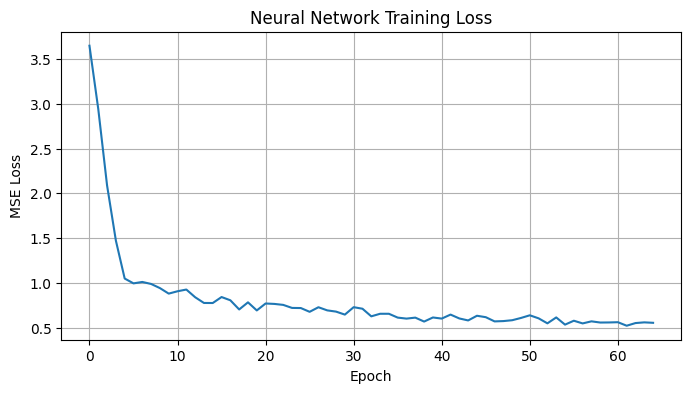

In [326]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Neural Network Training Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

The training loss decreases steadily across epochs, which means the neural network is learning useful patterns from the training data.

Lastly, we use our trained Neural Network model to make predictions on the test set and evaluate it using regression metrics (MSE, RMSE, MAE, and R^2).

In [327]:
nn_model.eval()
with torch.no_grad():
    test_predictions = nn_model(X_nn_test_tensor)

y_nn_true = y_nn_test_tensor.numpy().flatten()
y_nn_pred = test_predictions.numpy().flatten()

nn_mse = mean_squared_error(y_nn_true, y_nn_pred)
nn_rmse = nn_mse ** 0.5
nn_r2 = r2_score(y_nn_true, y_nn_pred)

print(f"Neural Network RMSE: {nn_rmse:.3f}")
print(f"Neural Network R²: {nn_r2:.3f}")

Neural Network RMSE: 0.722
Neural Network R²: 0.410


Our trained Neural Network model has an **RMSE** of **0.722** and an **R<sup>2</sup>** of **0.410**. Based on the final model's RMSE, the model's predictions are off by about 15% of the total range of alcohol_consumption. The final model's R<sup>2</sup> means that the model explains about 35.8% of the variance in alcohol_consumption, and while this seems low, it could be because the students' alcohol consumption could be determined by other factors that are not covered in the dataset. 

# **Comparison Between All 3 Models**

Here are the **Root Mean Square Error** and **R<sup>2</sup>** for all 3 of our chosen Machine Learning Models. Note that we want that we want RMSE to be close to 0 and R<sup>2</sup> to be close to 1

In [328]:
print(f"---Regularized Linear Regression (Ridge Regression)---")
print(f"RMSE: {rmse_final:.3f}")
print(f"R²: {r2_final:.3f}\n")

print(f"---Decision Tree---")
print(f"RMSE: {rmse_decisiontree:.3f}")
print(f"R²: {r2_decisiontree:.3f}\n")

print(f"---Neural Network---")
print(f"RMSE: {nn_rmse:.3f}")
print(f"R²: {nn_r2:.3f}")

---Regularized Linear Regression (Ridge Regression)---
RMSE: 0.745
R²: 0.319

---Decision Tree---
RMSE: 0.810
R²: 0.195

---Neural Network---
RMSE: 0.722
R²: 0.410


In terms of **R<sup>2</sup>**, **Neural Network** is the best performing model, while Decision Tree shows a notable drop compared to Neural Network and Regularized Linear Regression. In terms of **RMSE**, **Regularized Linear Regression** narrowly beats Neural Network, while Decision Tree significantly falls behind both of them. Between Regularized Linear Regression and Neural Network, the former has slightly more acurate predictions while the former explains more of the variance in alcohol_consumption. 

Given these results, we conclude that **Neural Network** is the best machine learning model for predicting a student's alcohol consumption based on the Student Performance dataset. Its success compared to the other 2 machine learning models could be attributed to neural networks being better at getting patterns than classical models. 

Our best performing models exhibit near moderate performance in predicting alcohol consumption. This could be because students' real life alcohol consumption are dependent on a variety of lifestyle and socio-cultural factors that are not within the scope of the Student Performance dataset.

# Declaration of AI Use

We used **ChatGPT** and **Claude** for assistance in the following tasks for each of these sections of our notebook:

_Exploratory Data Analysis_
* Advice on how to deal with categorical variables in the dataset
* Advice on how to resolve NaN values after merging Math and Portuguese datasets

_Regularized Linear Regression_
* Providing pseudo code on neural network implementation
* Choosing initial values for alpha in Hyperparameter Tuning

_Decision Tree_
* part 1
* part 2

_Neural Network Model_
* Advice on how to improve a neural network
* Providing pseudo code on neural network implementation
* Reviewing python syntax relevant for neural network
* Explaining stratify and binning
* Explain how to use ReduceLROnPlateau

_Comparison Between All 3 Models_
* Interpretation of RMSE and R<sup>2</sup> values